In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt

from sklearn.model_selection import GridSearchCV

from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import DecisionTreeClassifier
from astroML.datasets import fetch_sdss_specgals
import sklearn
from astroML.utils import completeness_contamination

In [2]:
file='sample_2e7_design_precessing_higherordermodes_3detectors.h5'

data = h5py.File(file, 'r')
list(data.keys())

z=np.array(data['z'])[0:int(1e5)]
ra=np.array(data['ra'])[0:int(1e5)]
dec=np.array(data['dec'])[0:int(1e5)]
mtot=np.array(data['mtot'])[0:int(1e5)]
q=np.array(data['q'])[0:int(1e5)]
chi1x=np.array(data['chi1x'])[0:int(1e5)]
chi1y=np.array(data['chi1y'])[0:int(1e5)]
chi1z=np.array(data['chi1z'])[0:int(1e5)]
chi2x=np.array(data['chi2x'])[0:int(1e5)]
chi2y=np.array(data['chi2y'])[0:int(1e5)]
chi2z=np.array(data['chi2z'])[0:int(1e5)]
iota=np.array(data['iota'])[0:int(1e5)]
psi=np.array(data['psi'])[0:int(1e5)]

det=np.array(data['det'])[0:int(1e5)]

X=np.stack([mtot, q, chi1x, chi1y, chi1z, chi2x, chi2y, chi2z, ra, dec, iota, psi, z])

X=np.transpose(X)
y=det

from sklearn.model_selection import train_test_split

Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.3, random_state=42)

completeness [0.79708468 0.79708468 0.78435909 0.76399815 0.81397501 0.85816752
 0.85909301 0.83155946 0.83965757 0.83734382 0.82901435 0.82993984
 0.83734382 0.83341046 0.8257751  0.82045349 0.81929662 0.82068487
 0.81628876 0.82022212]
contamination [0.24102225 0.24102225 0.19858156 0.14984552 0.16516374 0.17006042
 0.16014476 0.13041374 0.13512869 0.14343195 0.14220733 0.15380986
 0.15876337 0.15465853 0.16631628 0.16760563 0.16760696 0.16619652
 0.16713881 0.16920553]
9


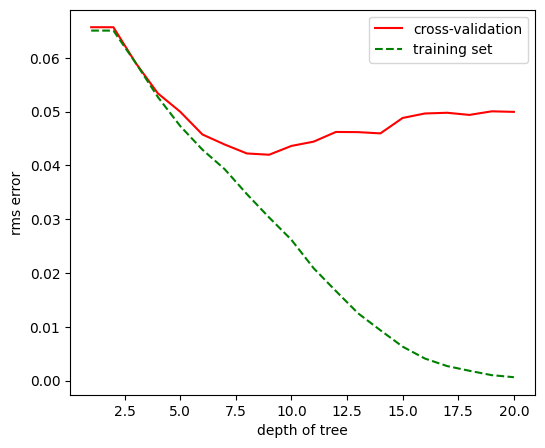

In [3]:
depth = np.arange(1, 21)
rms_test = np.zeros(len(depth))
rms_train = np.zeros(len(depth))
completenesstrain = np.zeros(len(depth))
contaminationtrain = np.zeros(len(depth))
completenesstest = np.zeros(len(depth))
contaminationtest = np.zeros(len(depth))
i_best = 0
yfit_best = None

for i, d in enumerate(depth):
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(Xtrain, ytrain)

    yfit_train = clf.predict(Xtrain)
    yfit = clf.predict(Xtest)
    rms_train[i] = np.mean(np.sqrt((yfit_train - ytrain) ** 2))
    rms_test[i] = np.mean(np.sqrt((yfit - ytest) ** 2))

    completenesstest[i], contaminationtest[i] = completeness_contamination(yfit, ytest)
    completenesstrain[i], contaminationtrain[i] = completeness_contamination(yfit_train, ytrain)

    if rms_test[i] <= rms_test[i_best]:
        i_best = i
        yfit_best = yfit

best_depth = depth[i_best]

fig = plt.figure(figsize=(6, 5))

ax = fig.add_subplot(111)
ax.plot(depth, rms_test, '-r', label='cross-validation')
ax.plot(depth, rms_train, '--g', label='training set')
ax.set_xlabel('depth of tree')
ax.set_ylabel('rms error')
ax.yaxis.set_major_locator(plt.MultipleLocator(0.01))
ax.legend(loc=1);

print("completeness", completenesstest)
print("contamination", contaminationtest)

print(best_depth)

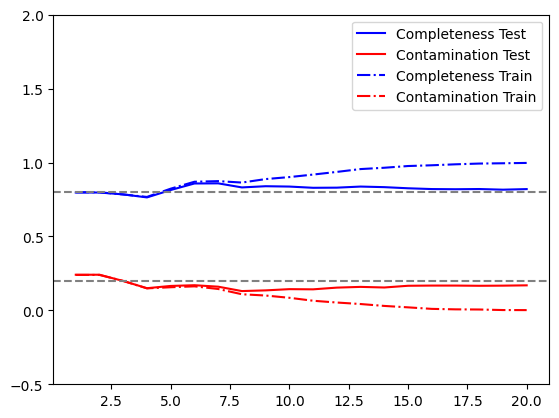

In [4]:
plt.plot(depth, completenesstest,'b', label='Completeness Test')
plt.plot(depth, contaminationtest,'r', label='Contamination Test')
plt.plot(depth, completenesstrain,'-.b', label='Completeness Train' )
plt.plot(depth, contaminationtrain,'-.r', label='Contamination Train')
plt.axhline(0.8, c='gray', ls='--')
plt.axhline(0.2, c='gray', ls='--')
plt.legend(loc='upper right');
plt.ylim(-0.5,2);

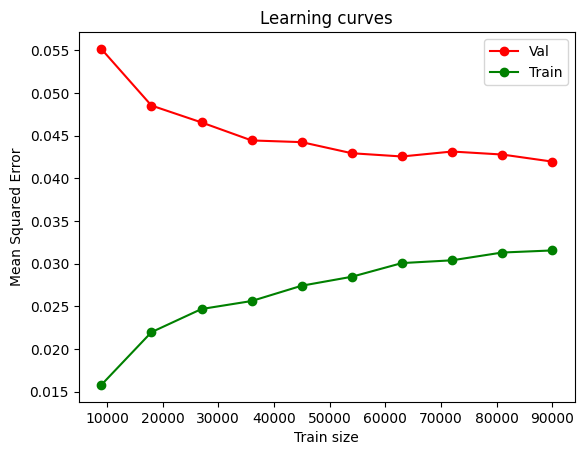

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import learning_curve

scaler = StandardScaler()
Xscaled = scaler.fit_transform(X)

clf = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
train_sizes, train_scores_clf, test_scores_clf = \
    learning_curve(clf, Xscaled, y, train_sizes=np.linspace(0.1, 1, 10), \
    scoring="neg_mean_squared_error", cv=10)


plt.plot(train_sizes, -test_scores_clf.mean(1), 'o-', color="r", label="Val")
plt.plot(train_sizes, -train_scores_clf.mean(1), 'o-', color="g", label="Train")
                   
plt.xlabel("Train size")
plt.ylabel("Mean Squared Error")
plt.title('Learning curves')
plt.legend(loc="best");

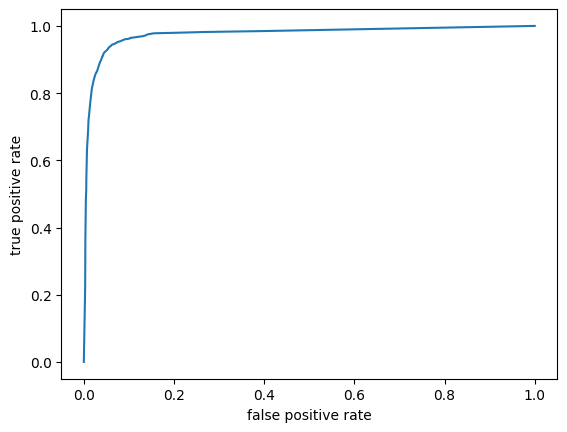

In [6]:
clf = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
clf.fit(Xtrain, ytrain)

yfit_train = clf.predict(Xtrain)
yfit = clf.predict(Xtest)

y_prob = clf.predict_proba(Xtest)[:,1]
fpr, tpr, thresholds = sklearn.metrics.roc_curve(ytest, y_prob)

plt.plot(fpr,tpr)

plt.xlabel('false positive rate')
plt.ylabel('true positive rate');

In [7]:
print(sklearn.metrics.confusion_matrix(ytest, yfit))

[[25111   567]
 [  693  3629]]


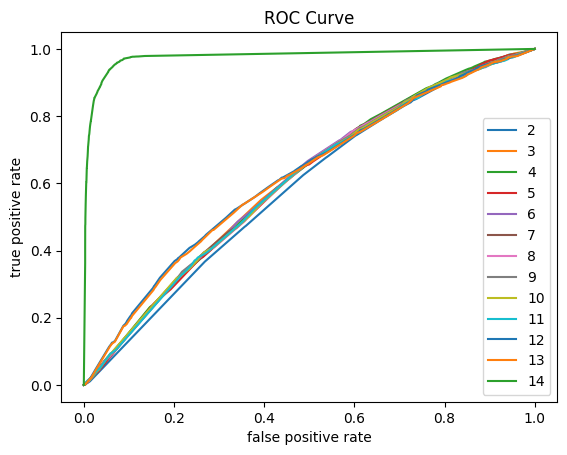

In [8]:
from sklearn.metrics import precision_recall_curve, roc_curve

classifiers = []
predictions = []
Nfeatures = np.arange(1, X.shape[1] + 1)


for nc in Nfeatures:
    clf = DecisionTreeClassifier(random_state=42, max_depth=best_depth,criterion='entropy')
    clf.fit(Xtrain[:, :nc], ytrain)
    y_pred = clf.predict(Xtest[:, :nc])

    classifiers.append(clf)
    predictions.append(y_pred)
    
    y_prob = clf.predict_proba(Xtest[:,:nc]) [:,1] 
    
    fpr, tpr, thresh = roc_curve(ytest, y_prob)
    plt.plot(fpr, tpr, label=str(nc+1))

plt.title("ROC Curve")
plt.legend()
plt.xlabel('false positive rate')
plt.ylabel('true positive rate');